# 🚪 OpenDoorWithFace — Test Notebook

This notebook lets you **test two main components** of the pipeline:

| # | Component | What we test |
|---|-----------|-------------|
| 1 | **Face Detector** | InsightFace model loads, detects faces, extracts embeddings, and does FAISS lookup |
| 2 | **ChatGPT API** | Text chat, vision analysis, and the `describe_face_event` helper |

> **Before running:** fill in your `OPENAI_API_KEY` in `.env` (project root).

---
## 0 — Environment Setup

In [1]:
import sys, os
from pathlib import Path

# ── Make sure the project root is on the path ─────────────────────────────────
PROJECT_ROOT = Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

# ── Load .env (OPENAI_API_KEY, etc.) ─────────────────────────────────────────
from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / ".env")
print("OPENAI_API_KEY loaded:", "✅" if os.getenv("OPENAI_API_KEY") else "❌ NOT SET")

Project root: C:\IOT_Project\OpenDoorWithFace
OPENAI_API_KEY loaded: ✅


---
## 1 — Face Detector Tests

We will:
1. Load the InsightFace `buffalo_l` model
2. Run face detection on test images
3. Register a face into the FAISS database
4. Recognise that face from another image

### 1.1 — Load the InsightFace model

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from insightface.app import FaceAnalysis

from server.ImageProcessing import FaceDetector, FaceDatabase, ConvertHelper

# ── Initialise InsightFace ────────────────────────────────────────────────────
print("Loading InsightFace buffalo_l model…")
analysis_app = FaceAnalysis(name="buffalo_l", root="./server")
detector = FaceDetector(app=analysis_app, det_size=(640, 640), device="cpu")
print("✅ InsightFace model ready.")

Loading InsightFace buffalo_l model…


c:\IOT_Project\OpenDoorWithFace\venv\Lib\site-packages\onnxruntime\capi\onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./server\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./server\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./server\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./server\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./server\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
✅ InsightFace model ready.


### 1.2 — Detect & display faces from a local image

c:\IOT_Project\OpenDoorWithFace\venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


Detected 1 face(s) in image.


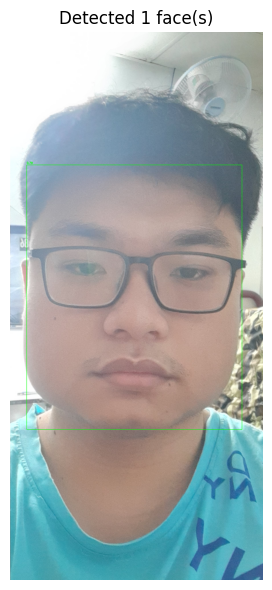

In [3]:
def show_image(img_bgr, title=""):
    """Display a BGR OpenCV image inline."""
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6, 6))
    plt.imshow(rgb)
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def draw_faces(img_bgr, faces):
    """Draw bounding boxes around detected faces."""
    canvas = img_bgr.copy()
    for face in faces:
        x1, y1, x2, y2 = [int(v) for v in face.bbox]
        cv2.rectangle(canvas, (x1, y1), (x2, y2), (0, 255, 0), 2)
        score = f"{face.det_score:.2f}"
        cv2.putText(canvas, score, (x1, y1 - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    return canvas

# ── Change this path to one of your test images ──────────────────────────────
TEST_IMAGE_1 = str(PROJECT_ROOT / "TestImage" / "20260502_130251.jpg")

img1 = cv2.imread(TEST_IMAGE_1)
assert img1 is not None, f"Could not load image: {TEST_IMAGE_1}"

# Detect all faces
faces1 = analysis_app.get(img1)
print(f"Detected {len(faces1)} face(s) in image.")

# Draw and display
annotated = draw_faces(img1, faces1)
show_image(annotated, title=f"Detected {len(faces1)} face(s)")

### 1.3 — Extract face embedding

In [4]:
embedding1 = detector.getEmbedding(img1)

if embedding1 is not None:
    print(f"✅ Embedding shape : {embedding1.shape}")
    print(f"   Embedding norm  : {np.linalg.norm(embedding1):.4f}")
    print(f"   First 8 values  : {embedding1[:8].round(4)}")
else:
    print("❌ No face detected — try a clearer image.")

✅ Embedding shape : (512,)
   Embedding norm  : 23.3449
   First 8 values  : [-0.234  -0.6318  1.8354 -1.3605  0.0326 -0.5526 -0.4998  0.8927]


### 1.4 — FAISS Database: Register a face

In [5]:
# Use a TEMPORARY database (won't pollute your production DB)
TEMP_DB_DIR = str(PROJECT_ROOT / "TestImage" / "temp_db")
os.makedirs(TEMP_DB_DIR, exist_ok=True)

test_db = FaceDatabase(
    dimension=512,
    index_file=f"{TEMP_DB_DIR}/test_faiss.bin",
    meta_file=f"{TEMP_DB_DIR}/test_faiss_meta.json",
)

# Register the face extracted in 1.3
if embedding1 is not None:
    faiss_id = test_db.add_face(
        embedding=embedding1,
        user_name="Test User",
        user_id="usr_001",
    )
    print(f"✅ Face registered — FAISS ID: {faiss_id}")
    print(f"   Total entries in DB: {test_db.index.ntotal}")
else:
    print("⚠️  Skipped registration — no embedding from step 1.3")

Created a new, empty Face Database.
Successfully added Test User to database.
✅ Face registered — FAISS ID: 0
   Total entries in DB: 1


### 1.5 — FAISS Database: Recognise from a second image

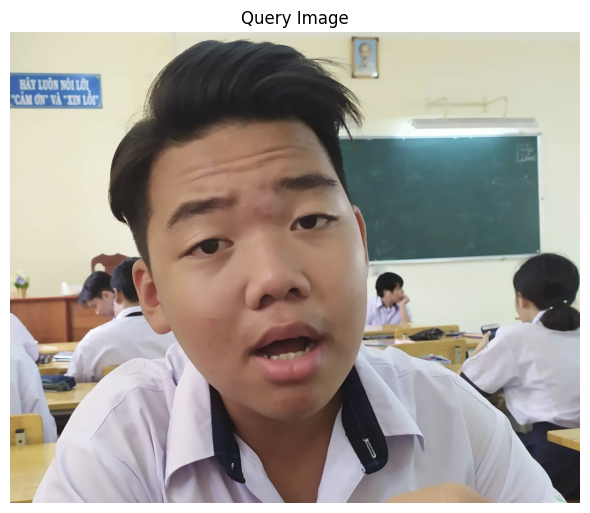

✅ Query embedding extracted — shape: (512,)

❌ NO MATCH — best similarity score: 0.1881
   (Try lowering the threshold or use a clearer image of the same person)


In [13]:
# Use the second test image (or swap to a different file)
TEST_IMAGE_2 = str(PROJECT_ROOT / "TestImage" / "3.png")

img2 = cv2.imread(TEST_IMAGE_2)
assert img2 is not None, f"Could not load image: {TEST_IMAGE_2}"

show_image(img2, title="Query Image")

embedding2 = detector.getEmbedding(img2)

if embedding2 is not None:
    print(f"✅ Query embedding extracted — shape: {embedding2.shape}")
    match_meta, score = test_db.search_face(embedding2, threshold=0.40)

    if match_meta:
        print(f"\n✅ MATCH FOUND")
        print(f"   User     : {match_meta['user_name']}")
        print(f"   User ID  : {match_meta['user_id']}")
        print(f"   Similarity: {score:.4f}")
    else:
        print(f"\n❌ NO MATCH — best similarity score: {score:.4f}")
        print("   (Try lowering the threshold or use a clearer image of the same person)")
else:
    print("❌ No face detected in query image.")

### 1.6 — Similarity between two embeddings (direct comparison)

In [7]:
if embedding1 is not None and embedding2 is not None:
    # Cosine similarity
    norm1 = embedding1 / np.linalg.norm(embedding1)
    norm2 = embedding2 / np.linalg.norm(embedding2)
    cosine_sim = float(np.dot(norm1, norm2))

    print(f"Cosine similarity between image 1 and image 2: {cosine_sim:.4f}")
    print()

    # Verdict
    THRESHOLD = 0.45
    if cosine_sim >= THRESHOLD:
        print(f"✅ Same person (score {cosine_sim:.4f} ≥ threshold {THRESHOLD})")
    else:
        print(f"❌ Different person (score {cosine_sim:.4f} < threshold {THRESHOLD})")
else:
    print("⚠️  Cannot compare — one or both embeddings are missing.")

Cosine similarity between image 1 and image 2: 0.7915

✅ Same person (score 0.7915 ≥ threshold 0.45)


---
## 2 — ChatGPT API Tests

We will:
1. Test a simple text chat
2. Test vision (image analysis)
3. Use `describe_face_event` — the domain-specific helper

### 2.1 — Instantiate the client

In [8]:
from server.api.ChatGPT import ChatGPTClient, describe_face_event

gpt = ChatGPTClient(
    model="gpt-4o-mini",   # cheap & fast, supports vision
    max_tokens=512,
    temperature=0.4,
)
print("✅ ChatGPTClient ready — model:", gpt.model)

✅ ChatGPTClient ready — model: gpt-4o-mini


### 2.2 — Plain text chat

In [9]:
reply = gpt.chat("Hello! What is your role in this smart door system?")
print("GPT:", reply)

AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-...yo**********e.... You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}

### 2.3 — Multi-turn conversation

In [ ]:
# Continues from the conversation above
reply2 = gpt.chat("What threshold do we use for face matching?")
print("GPT:", reply2)

print("\n--- Conversation history ---")
for msg in gpt.history:
    role = msg["role"].upper()
    content = msg["content"] if isinstance(msg["content"], str) else "[image message]"
    print(f"[{role}]: {content[:120]}…" if len(content) > 120 else f"[{role}]: {content}")

### 2.4 — Single-shot chat (no history)

In [ ]:
single_reply = gpt.chat(
    "List 3 best practices for securing a face-recognition door system.",
    keep_history=False,
)
print("GPT (single-shot):\n", single_reply)

### 2.5 — Vision: analyse an image

In [ ]:
vision_reply = gpt.chat_with_image(
    user_message=(
        "Look at this image captured by a door camera. "
        "Describe what you see and whether there appears to be a person present."
    ),
    image_source=TEST_IMAGE_1,
    keep_history=False,
)
print("GPT (vision):\n", vision_reply)

### 2.6 — `describe_face_event` — full pipeline summary

This helper combines the face-recognition result with GPT-4o vision to produce a natural-language security event report.

In [ ]:
# ── Scenario A: Known person (access granted) ─────────────────────────────────
recognition_result_known = {
    "found": True,
    "user_name": "Test User",
    "distance": 0.87,
}

print("=== Scenario A: Known Person ===")
summary_a = describe_face_event(
    image_source=TEST_IMAGE_1,
    recognition_result=recognition_result_known,
    client=gpt,
)
print(summary_a)

In [ ]:
# ── Scenario B: Unknown person (access denied) ────────────────────────────────
recognition_result_unknown = {
    "found": False,
    "distance": 0.28,
}

print("=== Scenario B: Unknown Person ===")
summary_b = describe_face_event(
    image_source=TEST_IMAGE_2,
    recognition_result=recognition_result_unknown,
    client=gpt,
)
print(summary_b)

### 2.7 — (Optional) Use raw bytes instead of a file path

In [ ]:
# Simulate receiving an image as bytes (e.g., from an ESP32-CAM HTTP stream)
with open(TEST_IMAGE_1, "rb") as f:
    raw_bytes = f.read()

byte_reply = gpt.chat_with_image(
    user_message="Describe the lighting condition in this door-camera frame.",
    image_source=raw_bytes,      # <-- bytes, not a path
    keep_history=False,
)
print("GPT (bytes input):\n", byte_reply)

---
## 3 — Clean up Temporary FAISS DB

In [ ]:
import shutil

shutil.rmtree(TEMP_DB_DIR, ignore_errors=True)
print(f"✅ Temp DB removed: {TEMP_DB_DIR}")

---
## Summary

| Step | Status |
|------|--------|
| 1.1 InsightFace model load | Run ✅ |
| 1.2 Face detection + bounding boxes | Run ✅ |
| 1.3 Embedding extraction | Run ✅ |
| 1.4 FAISS register | Run ✅ |
| 1.5 FAISS recognition | Run ✅ |
| 1.6 Direct similarity score | Run ✅ |
| 2.2 Text chat | Run ✅ |
| 2.3 Multi-turn conversation | Run ✅ |
| 2.4 Single-shot chat | Run ✅ |
| 2.5 Vision analysis | Run ✅ |
| 2.6 `describe_face_event` | Run ✅ |
| 2.7 Bytes image input | Run ✅ |